# Classificação Supervisionada com KMeans no Dataset Adult (Balanceado)

Este notebook apresenta um pipeline **didático e numerado** para classificação supervisionada utilizando KMeans no dataset Adult, **com balanceamento das classes** via oversampling. O objetivo é comparar o desempenho do agrupamento com e sem desbalanceamento, detalhando cada etapa do processo.

## 1. Importação das Bibliotecas

In [11]:
# ===============================
# 1. Importação das Bibliotecas
# ===============================
# Importa todas as bibliotecas necessárias para manipulação de dados, visualização, pré-processamento e clustering.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
from sklearn.cluster import KMeans
import os
import seaborn as sns
from sklearn.decomposition import PCA

# Define o diretório para salvar imagens
img_dir = 'img'
os.makedirs(img_dir, exist_ok=True)

## 2. Carregamento e Balanceamento dos Dados

O dataset Adult é carregado e a classe minoritária (>50K) é balanceada por oversampling, igualando a quantidade de exemplos das duas classes. Isso evita que o modelo favoreça a classe majoritária.

In [12]:
# Carrega o dataset Adult, define nomes das colunas e transforma a variável alvo em binária
adult_df_raw = pd.read_csv('data/AdultDataset/adult.data', header=None, na_values=' ?', skipinitialspace=True)
adult_df_raw.columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'income'
]
# income_bin: 1 se >50K, 0 caso contrário
adult_df_raw['income_bin'] = adult_df_raw['income'].apply(lambda val: 1 if val.strip() == '>50K' else 0)

# Remove linhas com valores ausentes
adult_df = adult_df_raw.dropna().copy()

# Separa as classes majoritária e minoritária
# Classe 0: <=50K (maioria), Classe 1: >50K (minoria)
df_majority = adult_df[adult_df['income_bin'] == 0]
df_minority = adult_df[adult_df['income_bin'] == 1]

# Oversampling: replica exemplos da minoria até igualar a maioria
n_majority = len(df_majority)
df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=n_majority,
    random_state=42
)

# Junta as duas classes e embaralha
adult_df_balanced = pd.concat([df_majority, df_minority_upsampled])
adult_df_balanced = adult_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Exibe a nova distribuição das classes
print('Distribuição após balanceamento:')
print(adult_df_balanced['income_bin'].value_counts())

Distribuição após balanceamento:
income_bin
1    24720
0    24720
Name: count, dtype: int64


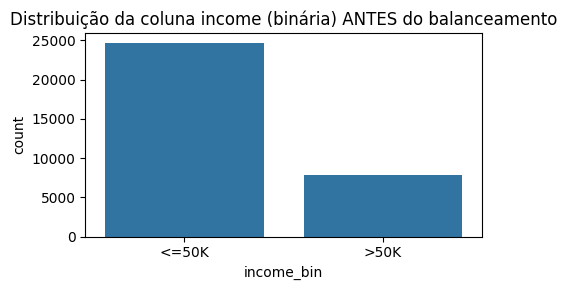

In [13]:
# Visualiza e salva o gráfico de frequência das classes antes do balanceamento
plt.figure(figsize=(5,3))
sns.countplot(x=adult_df['income_bin'])
plt.title('Distribuição da coluna income (binária) ANTES do balanceamento')
plt.xticks([0,1],["<=50K",">50K"])
plt.tight_layout()
plt.savefig(os.path.join(img_dir, 'kmeans_adult_freq_classes_antes_balanceamento.png'))
plt.show()


## 3. Pré-processamento dos Dados

As variáveis categóricas são codificadas numericamente, os dados são normalizados e a distribuição da variável alvo é visualizada. O pré-processamento garante que o KMeans funcione corretamente, pois o algoritmo é sensível à escala dos dados.

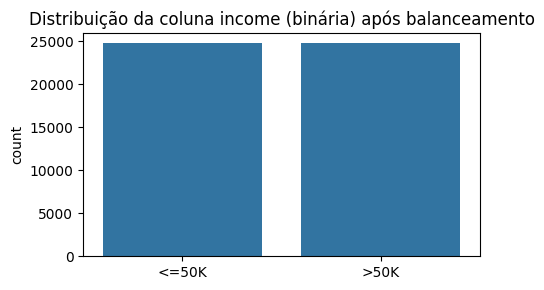

In [14]:
# Codifica variáveis categóricas (exceto a coluna alvo original 'income')
for col in adult_df_balanced.select_dtypes(include='object').columns:
    if col != 'income':
        adult_df_balanced[col] = LabelEncoder().fit_transform(adult_df_balanced[col].astype(str))

# Separa features e alvo binário
y = adult_df_balanced['income_bin'].values
X = adult_df_balanced.drop(['income', 'income_bin'], axis=1).values

# Normaliza os dados para média 0 e desvio padrão 1
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Visualiza a distribuição da variável alvo após balanceamento
plt.figure(figsize=(5,3))
sns.countplot(x=y)
plt.title('Distribuição da coluna income (binária) após balanceamento')
plt.xticks([0,1],["<=50K",">50K"])
plt.tight_layout()
plt.savefig(os.path.join(img_dir, 'kmeans_adult_balance_class_distribution.png'))
plt.show()

## 4. Divisão em Treino/Teste

Os dados balanceados são divididos em conjuntos de treino e teste de forma estratificada, preservando a proporção das classes.

In [15]:
# Divide o dataset balanceado em treino (70%) e teste (30%) de forma estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

## 5. Definição do Número de Clusters

Definimos o número de clusters a ser utilizado pelo KMeans, com base em conhecimento prévio ou método do cotovelo.

In [16]:
# Define o número de clusters (ajuste conforme o método do cotovelo ou conhecimento prévio)
n_clusters = 8

## 6. Implementação do KMeans Supervisionado

Criação de uma classe que associa cada cluster ao rótulo mais frequente no treino, permitindo avaliação supervisionada.

In [17]:
# Classe para KMeans supervisionado: associa cada cluster ao rótulo mais frequente no treino
class KMeansSupervisionado:
    def __init__(self, n_clusters=n_clusters, random_state=0):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
        self.cluster_labels_ = None

    def fit(self, X, y):
        # Ajusta o KMeans e associa cada cluster ao rótulo mais frequente
        clusters = self.kmeans.fit_predict(X)
        self.cluster_labels_ = []
        for i in range(self.n_clusters):
            mask = (clusters == i)
            if np.any(mask):
                label = np.bincount(y[mask]).argmax()
            else:
                label = -1
            self.cluster_labels_.append(label)

    def predict(self, X):
        # Prediz o cluster e converte para o rótulo associado
        clusters = self.kmeans.predict(X)
        return np.array([self.cluster_labels_[c] for c in clusters])

    def evaluate(self, X, y_true):
        # Avalia acurácia e matriz de confusão
        y_pred = self.predict(X)
        acc = accuracy_score(y_true, y_pred)
        cm = confusion_matrix(y_true, y_pred)
        return acc, cm

## 7. Treinamento e Avaliação Inicial

Treinamento do modelo no conjunto de treino e avaliação inicial no conjunto de teste, incluindo visualização da matriz de confusão.

Acurácia: 0.7198
Matriz de Confusão:
[[5043 2373]
 [1783 5633]]


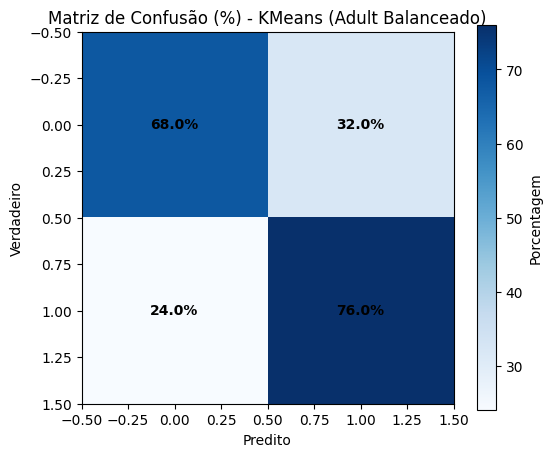

In [18]:
# Treina o KMeans supervisionado e avalia no conjunto de teste
clf = KMeansSupervisionado(n_clusters=n_clusters, random_state=30)
clf.fit(X_train, y_train)
acc, cm = clf.evaluate(X_test, y_test)
print(f'Acurácia: {acc:.4f}')
print('Matriz de Confusão:')
print(cm)

# Visualiza a matriz de confusão com valores nas células
plt.figure(figsize=(6,5))
cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100
plt.imshow(cm_percent, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusão (%) - KMeans (Adult Balanceado)')
plt.colorbar(label='Porcentagem')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
for i in range(cm_percent.shape[0]):
    for j in range(cm_percent.shape[1]):
        plt.text(j, i, f'{cm_percent[i, j]:.1f}%', ha='center', va='center', color='black', fontsize=10, fontweight='bold')
plt.savefig(f'{img_dir}/kmeans_adult_balance_confusion_matrix.png')
plt.show()

## 8. Visualização dos Agrupamentos com PCA

Redução de dimensionalidade dos dados para 2D usando PCA e visualização dos agrupamentos e centros dos clusters em gráfico de dispersão.

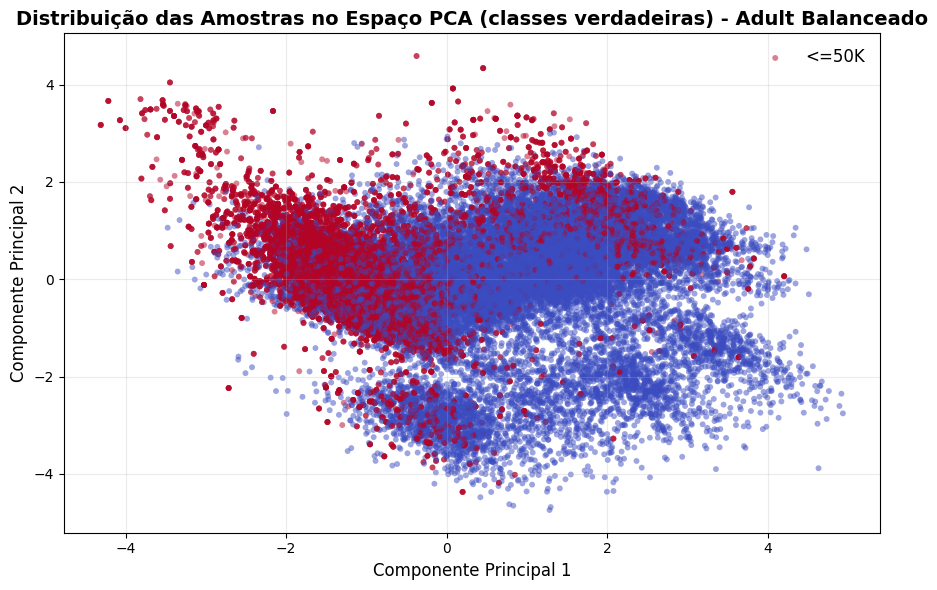

Acurácia: 0.7198
Matriz de Confusão:
[[5043 2373]
 [1783 5633]]


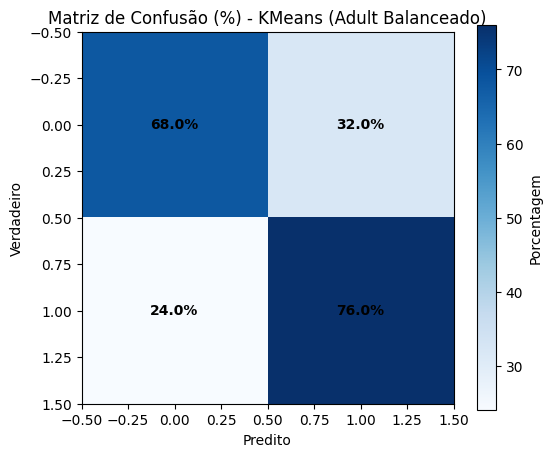

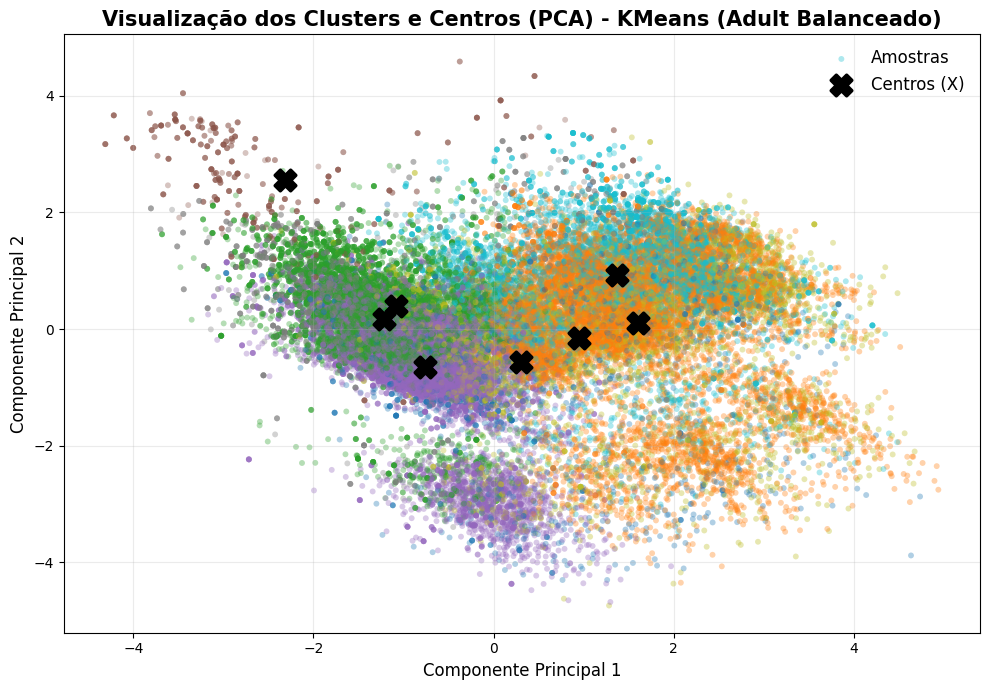

In [19]:
# Redução de dimensionalidade para 2D com PCA (antes do clustering)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Visualização dos dados no espaço 2D do PCA, colorindo pelas classes verdadeiras
plt.figure(figsize=(9,6))
plt.scatter(
    X_pca[:,0], X_pca[:,1], 
    c=y, cmap='coolwarm', alpha=0.5, s=18, edgecolor='none', label='Amostras'
    )
plt.title('Distribuição das Amostras no Espaço PCA (classes verdadeiras) - Adult Balanceado', fontsize=14, fontweight='bold')
plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)
plt.grid(alpha=0.25)
plt.legend(['<=50K', '>50K'], frameon=False, fontsize=12, loc='best')
plt.tight_layout()
plt.savefig(os.path.join(img_dir, 'kmeans_adult_balance_pca_true_labels.png'), dpi=150)
plt.show()

# Ajusta o KMeans nos dados completos para obter os clusters e centros
cls = KMeans(n_clusters=n_clusters, random_state=42)
clusters = cls.fit_predict(X)
centros = cls.cluster_centers_
centros_pca = pca.transform(centros)
acc, cm = clf.evaluate(X_test, y_test)

print(f'Acurácia: {acc:.4f}')
print('Matriz de Confusão:')
print(cm)
plt.figure(figsize=(6,5))
cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100
plt.imshow(cm_percent, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusão (%) - KMeans (Adult Balanceado)')
plt.colorbar(label='Porcentagem')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
# Adiciona os valores nas células
for i in range(cm_percent.shape[0]):
    for j in range(cm_percent.shape[1]):
        plt.text(j, i, f'{cm_percent[i, j]:.1f}%', ha='center', va='center', color='black', fontsize=10, fontweight='bold')
plt.savefig(f'{img_dir}/kmeans_adult_balance_confusion_matrix.png')
plt.show()

# Gráfico 2D dos clusters e centros (X em preto)
plt.figure(figsize=(10,7))
plt.scatter(
    X_pca[:,0], X_pca[:,1], 
    c=clusters, cmap='tab10', alpha=0.35, s=18, edgecolor='none', label='Amostras'
    )
plt.scatter(
    centros_pca[:,0], centros_pca[:,1], 
    c='black', marker='X', s=220, linewidths=2.5, zorder=4, label='Centros (X)'
    )
plt.title('Visualização dos Clusters e Centros (PCA) - KMeans (Adult Balanceado)', fontsize=15, fontweight='bold')
plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)
plt.grid(alpha=0.25)
plt.legend(frameon=False, fontsize=12, loc='best')
plt.tight_layout()
plt.savefig(os.path.join(img_dir, 'kmeans_adult_balance_clusters_pca.png'), dpi=150)
plt.show()

## 9. Repetição dos Experimentos e Análise Quantitativa

Execução do experimento múltiplas vezes com diferentes seeds, cálculo de métricas agregadas (média, desvio padrão, matriz de confusão média, precisão, recall, F1-score) e geração de gráficos para análise de robustez. Todos os resultados são salvos para análise posterior.

MSE médio: 0.2883
Desvio padrão do MSE: 0.0160
Acurácia média: 0.7117
Desvio padrão da acurácia: 0.0160
Acurácia global: 0.7117
Precisão (macro): 0.7144
Recall (macro): 0.7117
F1-score (macro): 0.7108
Matriz de Confusão Média:
[[4863 2553]
 [1723 5693]]


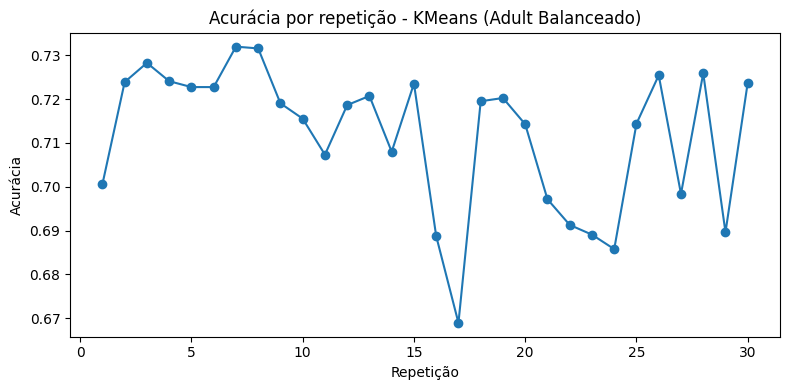

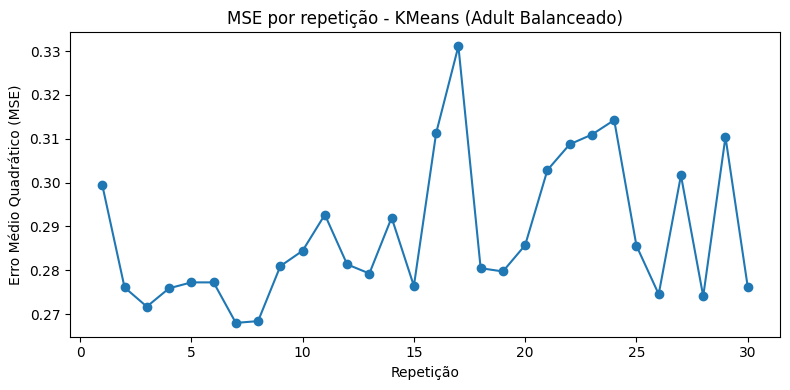

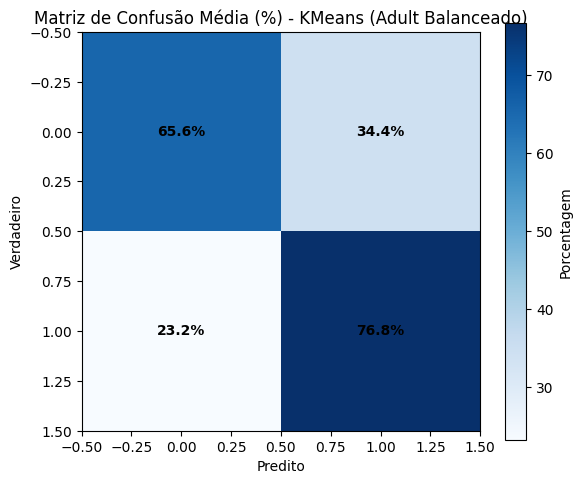

In [20]:
# ===============================
# 9. Repetição dos Experimentos e Análise Quantitativa (KMeans - Adult Balanceado)
# ===============================
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

n_repeats = 30
acuracias = []
mse_list = []
matrizes_confusao = []
y_true_all = []
y_pred_all = []

for seed in range(1, n_repeats+1):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = KMeansSupervisionado(n_clusters=n_clusters, random_state=seed)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    acuracias.append(acc)
    mse_list.append(mse)
    matrizes_confusao.append(confusion_matrix(y_test, y_pred))
    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)

# Conversão para numpy arrays
acuracias = np.array(acuracias)
mse_array = np.array(mse_list)
matrizes_confusao = np.array(matrizes_confusao)

# Estatísticas globais
mse_medio = mse_array.mean()
mse_std = mse_array.std()
acc_medio = acuracias.mean()
acc_std = acuracias.std()

# Matriz de confusão média (inteira)
matriz_confusao_media = np.mean(matrizes_confusao, axis=0)
matriz_confusao_media_int = np.round(matriz_confusao_media).astype(int)

# Matriz de confusão média em porcentagem (por linha)
matriz_confusao_media_percent = matriz_confusao_media / matriz_confusao_media.sum(axis=1, keepdims=True) * 100

# Métricas macro globais
prec = precision_score(y_true_all, y_pred_all, average='macro')
rec = recall_score(y_true_all, y_pred_all, average='macro')
f1 = f1_score(y_true_all, y_pred_all, average='macro')

print(f'MSE médio: {mse_medio:.4f}')
print(f'Desvio padrão do MSE: {mse_std:.4f}')
print(f'Acurácia média: {acc_medio:.4f}')
print(f'Desvio padrão da acurácia: {acc_std:.4f}')
print(f"Acurácia global: {acc_medio:.4f}")
print(f"Precisão (macro): {prec:.4f}")
print(f"Recall (macro): {rec:.4f}")
print(f"F1-score (macro): {f1:.4f}")
print("Matriz de Confusão Média:")
print(matriz_confusao_media_int)

# Gráfico de acurácia por repetição
plt.figure(figsize=(8,4))
plt.plot(range(1, n_repeats+1), acuracias, marker='o')
plt.xlabel('Repetição')
plt.ylabel('Acurácia')
plt.title('Acurácia por repetição - KMeans (Adult Balanceado)')
plt.tight_layout()
plt.savefig(os.path.join(img_dir, 'kmeans_adult_balance_accuracy_repetitions.png'))
plt.show()

# Gráfico de MSE por repetição
plt.figure(figsize=(8,4))
plt.plot(range(1, n_repeats+1), mse_array, marker='o')
plt.xlabel('Repetição')
plt.ylabel('Erro Médio Quadrático (MSE)')
plt.title('MSE por repetição - KMeans (Adult Balanceado)')
plt.tight_layout()
plt.savefig(os.path.join(img_dir, 'kmeans_adult_balance_mse_repetitions.png'))
plt.show()

# Visualização da matriz de confusão média em porcentagem
plt.figure(figsize=(6,5))
plt.imshow(matriz_confusao_media_percent, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusão Média (%) - KMeans (Adult Balanceado)')
plt.colorbar(label='Porcentagem')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
for i in range(matriz_confusao_media_percent.shape[0]):
    for j in range(matriz_confusao_media_percent.shape[1]):
        plt.text(j, i, f'{matriz_confusao_media_percent[i, j]:.1f}%', ha='center', va='center', color='black', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(img_dir, 'kmeans_adult_balance_confusion_matrix_media_percent.png'))
plt.show()

# Salvar resultados para análise posterior
np.save(os.path.join(img_dir, 'kmeans_adult_balance_accuracies.npy'), acuracias)
np.savetxt(os.path.join(img_dir, 'kmeans_adult_balance_accuracies.csv'), acuracias, delimiter=',')
np.save(os.path.join(img_dir, 'kmeans_adult_balance_mse_repetitions.npy'), mse_array)
np.savetxt(os.path.join(img_dir, 'kmeans_adult_balance_mse_repetitions.csv'), mse_array, delimiter=',')
np.save(os.path.join(img_dir, 'kmeans_adult_balance_confusion_matrix_media.npy'), matriz_confusao_media)
np.savetxt(os.path.join(img_dir, 'kmeans_adult_balance_confusion_matrix_media.csv'), matriz_confusao_media, delimiter=',')
np.save(os.path.join(img_dir, 'kmeans_adult_balance_confusion_matrix_media_percent.npy'), matriz_confusao_media_percent)
np.savetxt(os.path.join(img_dir, 'kmeans_adult_balance_confusion_matrix_media_percent.csv'), matriz_confusao_media_percent, delimiter=',')